In [1]:
!pip -q install kaggle


In [3]:
import os
os.environ['KAGGLE_USERNAME'] = "sahar saidani"
os.environ['KAGGLE_KEY'] = "KGAT_b6db3b59bf6c178443698d0c3e71ac7d"

# Télécharger et dézipper le dataset
!kaggle datasets download -d emmarex/plantdisease -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:06<00:00, 99.4MB/s]



In [7]:
import json
import os
import random
import shutil
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 8
LR = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
DATASET_ROOT = Path("/content/data/PlantVillage")
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_CLASSES = [
    "Tomato_healthy",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Bacterial_spot",
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda


In [8]:
print("Dataset root exists:", DATASET_ROOT.exists())
for class_name in SELECTED_CLASSES:
    class_dir = DATASET_ROOT / class_name
    print(class_name, class_dir.exists(), len(list(class_dir.glob("*"))) if class_dir.exists() else 0)



Dataset root exists: True
Tomato_healthy True 1591
Tomato_Early_blight True 1000
Tomato_Late_blight True 1909
Tomato_Bacterial_spot True 2127


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(DATASET_ROOT)
idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}
selected_indices = [
    idx for idx, (_, label_idx) in enumerate(full_dataset.samples)
    if idx_to_class[label_idx] in SELECTED_CLASSES
]

selected_samples = [full_dataset.samples[i] for i in selected_indices]
selected_targets = [label for _, label in selected_samples]

class_to_new_idx = {name: i for i, name in enumerate(SELECTED_CLASSES)}

class FilteredPlantDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, old_label = self.samples[idx]
        class_name = idx_to_class[old_label]
        new_label = class_to_new_idx[class_name]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, new_label

base_dataset = FilteredPlantDataset(selected_samples, transform=None)
total_size = len(base_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset, test_subset = random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator,
)

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        path, _ = self.subset.dataset.samples[self.subset.indices[idx]]
        image = Image.open(path).convert("RGB")
        image = self.transform(image)
        return image, label

train_ds = TransformedSubset(train_subset, train_transform)
val_ds = TransformedSubset(val_subset, eval_transform)
test_ds = TransformedSubset(test_subset, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

Train: 4638 Val: 994 Test: 995


In [10]:
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(SELECTED_CLASSES))
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

print(model)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [11]:
history = []
best_val_acc = 0.0
best_model_path = OUTPUT_DIR / "best_model.pt"

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += inputs.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += inputs.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    scheduler.step(val_acc)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

print("Best val acc:", best_val_acc)

Epoch 1/8 | train_loss=0.8758 train_acc=0.7316 | val_loss=0.5824 val_acc=0.8853
Epoch 2/8 | train_loss=0.5025 train_acc=0.8734 | val_loss=0.4078 val_acc=0.9145
Epoch 3/8 | train_loss=0.3870 train_acc=0.8989 | val_loss=0.3245 val_acc=0.9296
Epoch 4/8 | train_loss=0.3307 train_acc=0.9118 | val_loss=0.2848 val_acc=0.9366
Epoch 5/8 | train_loss=0.2985 train_acc=0.9166 | val_loss=0.2610 val_acc=0.9356
Epoch 6/8 | train_loss=0.2697 train_acc=0.9258 | val_loss=0.2272 val_acc=0.9386
Epoch 7/8 | train_loss=0.2538 train_acc=0.9248 | val_loss=0.2141 val_acc=0.9437
Epoch 8/8 | train_loss=0.2372 train_acc=0.9273 | val_loss=0.1964 val_acc=0.9467
Best val acc: 0.9466800804828974


In [12]:
for param in model.features.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)

FINE_TUNE_EPOCHS = 3
for epoch in range(FINE_TUNE_EPOCHS):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += inputs.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += inputs.size(0)

    val_acc = val_correct / val_total
    print(f"Fine-tune {epoch+1}/{FINE_TUNE_EPOCHS} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)


Fine-tune 1/3 | train_acc=0.9657 | val_acc=0.9869
Fine-tune 2/3 | train_acc=0.9894 | val_acc=0.9940
Fine-tune 3/3 | train_acc=0.9953 | val_acc=0.9960


In [13]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())

report = classification_report(y_true, y_pred, target_names=SELECTED_CLASSES, output_dict=True)
cm = confusion_matrix(y_true, y_pred)

print(classification_report(y_true, y_pred, target_names=SELECTED_CLASSES))


                       precision    recall  f1-score   support

       Tomato_healthy       1.00      1.00      1.00       251
  Tomato_Early_blight       0.98      0.99      0.99       133
   Tomato_Late_blight       1.00      0.99      0.99       295
Tomato_Bacterial_spot       1.00      1.00      1.00       316

             accuracy                           0.99       995
            macro avg       0.99      0.99      0.99       995
         weighted avg       1.00      0.99      0.99       995



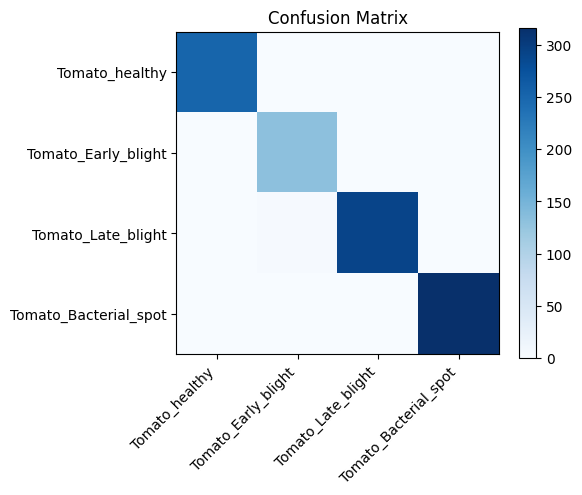

Artifacts saved in: /content/output
[PosixPath('/content/output/confusion_matrix.png'), PosixPath('/content/output/best_model.pt'), PosixPath('/content/output/training_summary.json'), PosixPath('/content/output/class_names.json')]


In [14]:
summary = {
    "selected_classes": SELECTED_CLASSES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "best_val_acc": best_val_acc,
    "test_accuracy": report["accuracy"],
    "macro_avg_f1": report["macro avg"]["f1-score"],
    "history": history,
}

with open(OUTPUT_DIR / "training_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

with open(OUTPUT_DIR / "class_names.json", "w") as f:
    json.dump(SELECTED_CLASSES, f, indent=2)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(SELECTED_CLASSES)), SELECTED_CLASSES, rotation=45, ha="right")
plt.yticks(range(len(SELECTED_CLASSES)), SELECTED_CLASSES)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=180)
plt.show()

print("Artifacts saved in:", OUTPUT_DIR)
print(list(OUTPUT_DIR.iterdir()))


In [15]:
from google.colab import files

files.download(str(OUTPUT_DIR / "best_model.pt"))
files.download(str(OUTPUT_DIR / "class_names.json"))
files.download(str(OUTPUT_DIR / "training_summary.json"))
files.download(str(OUTPUT_DIR / "confusion_matrix.png"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>